## **Charger les données**

In [ ]:
!unzip datasets.zip

Archive:  datasets.zip
   creating: datasets/
   creating: datasets/mtop_intent/
   creating: datasets/stackexchange/
   creating: datasets/arxiv_fine/
   creating: datasets/clinc/
   creating: datasets/few_nerd_nat/
   creating: datasets/few_event/
   creating: datasets/clinc_domain/
   creating: datasets/mtop_domain/
   creating: datasets/few_rel_nat/
   creating: datasets/massive_scenario/
   creating: datasets/banking77/
   creating: datasets/go_emotion/
   creating: datasets/reddit/
   creating: datasets/massive_intent/
  inflating: datasets/mtop_intent/large.jsonl  
  inflating: datasets/mtop_intent/small.jsonl  
  inflating: datasets/stackexchange/large.jsonl  
  inflating: datasets/stackexchange/small.jsonl  
  inflating: datasets/arxiv_fine/large.jsonl  
  inflating: datasets/arxiv_fine/small.jsonl  
  inflating: datasets/clinc/large.jsonl  
  inflating: datasets/clinc/small.jsonl  
  inflating: datasets/few_nerd_nat/large.jsonl  
  inflating: datasets/few_nerd_nat/small.jsonl

In [ ]:
!ls datasets

arxiv_fine  clinc_domain  few_rel_nat	  massive_scenario  reddit
banking77   few_event	  go_emotion	  mtop_domain	    stackexchange
clinc	    few_nerd_nat  massive_intent  mtop_intent


In [ ]:
!mv datasets dataset

In [ ]:
import json
import os

dataset_names = [
    "arxiv_fine",
    "go_emotion",
    "massive_intent",
    "massive_scenario",
    "mtop_intent"
]

DATASET_PATH = "dataset"

datasets = {}

for name in dataset_names:

    file_path = os.path.join(DATASET_PATH, name, "small.jsonl")

    texts = []
    labels = []

    with open(file_path, "r") as f:
        for line in f:
            data = json.loads(line)
            texts.append(data["input"])
            labels.append(data["label"])

    datasets[name] = {
        "texts": texts,
        "labels": labels
    }

    print(f"{name} loaded → {len(texts)} samples")

arxiv_fine loaded → 3674 samples
go_emotion loaded → 5940 samples
massive_intent loaded → 2974 samples
massive_scenario loaded → 2974 samples
mtop_intent loaded → 4386 samples


## **Select_part_labels**

In [ ]:
!mkdir generated_labels

In [ ]:
!python select_part_labels.py

Use dataset ./dataset/arxiv_fine/small.jsonl
Length of dataset: 3674
93
Choose num: 18
Use dataset ./dataset/banking77/small.jsonl
Length of dataset: 3080
77
Choose num: 15
Use dataset ./dataset/clinc/small.jsonl
Length of dataset: 4500
150
Choose num: 30
Use dataset ./dataset/clinc_domain/small.jsonl
Length of dataset: 4500
10
Choose num: 2
Use dataset ./dataset/few_event/small.jsonl
Length of dataset: 4742
34
Choose num: 6
Use dataset ./dataset/few_nerd_nat/small.jsonl
Length of dataset: 3789
58
Choose num: 11
Use dataset ./dataset/few_rel_nat/small.jsonl
Length of dataset: 4480
64
Choose num: 12
Use dataset ./dataset/go_emotion/small.jsonl
Length of dataset: 5940
27
Choose num: 5
Use dataset ./dataset/massive_intent/small.jsonl
Length of dataset: 2974
59
Choose num: 11
Use dataset ./dataset/massive_scenario/small.jsonl
Length of dataset: 2974
18
Choose num: 3
Use dataset ./dataset/mtop_domain/small.jsonl
Length of dataset: 4386
11
Choose num: 2
Use dataset ./dataset/mtop_intent/smal

## **label_generation**

In [ ]:
!pip uninstall -y mistralai
!pip install mistralai==0.4.2

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 41.9/41.9 kB 1.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 133.1/133.1 kB 6.6 MB/s eta 0:00:00
  Attempting uninstall: orjson
    Found existing installation: orjson 3.11.7
    Uninstalling orjson-3.11.7:
      Successfully uninstalled orjson-3.11.7
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
langgraph-sdk 0.3.11 requires orjson>=3.11.5, but you have orjson 3.10.18 which is incompatible.


In [ ]:
from mistralai.client import MistralClient
from mistralai.models.chat_completion import ChatMessage

client = MistralClient(api_key="Q14wFFcCeCi8KMv8SGHx7sOedaQQBYi9")

response = client.chat(
    model="mistral-large-latest",
    messages=[ChatMessage(role="user", content="Hello")]
)

print(response.choices[0].message.content)

Hello! 😊 How can I assist you today? Whether you have a question, need help with something, or just want to chat, I'm here for you!


In [ ]:
for dataset in ["arxiv_fine", "go_emotion", "massive_intent", "massive_scenario", "mtop_intent"]:
    !python label_generation.py --data {dataset} --max_samples 1000 --api_key "Q14wFFcCeCi8KMv8SGHx7sOedaQQBYi9"

Use dataset ./dataset/arxiv_fine/small.jsonl
Length of dataset: 1000
True cluster num: 25
Saved → ./generated_labels/arxiv_fine_small_true_labels.json
Processing 0/1000 (0.0%) | labels: 18
Processing 15/1000 (1.5%) | labels: 33
Processing 30/1000 (3.0%) | labels: 41
Processing 45/1000 (4.5%) | labels: 47
Processing 60/1000 (6.0%) | labels: 51
Processing 75/1000 (7.5%) | labels: 59
Processing 90/1000 (9.0%) | labels: 61
Processing 105/1000 (10.5%) | labels: 61
Processing 120/1000 (12.0%) | labels: 65
Processing 135/1000 (13.5%) | labels: 68
Processing 150/1000 (15.0%) | labels: 69
Processing 165/1000 (16.5%) | labels: 71
Processing 180/1000 (18.0%) | labels: 72
Processing 195/1000 (19.5%) | labels: 72
Processing 210/1000 (21.0%) | labels: 72
Processing 225/1000 (22.5%) | labels: 73
Processing 240/1000 (24.0%) | labels: 73
Processing 255/1000 (25.5%) | labels: 74
Processing 270/1000 (27.0%) | labels: 74
Processing 285/1000 (28.5%) | labels: 74
Processing 300/1000 (30.0%) | labels: 74
Pro

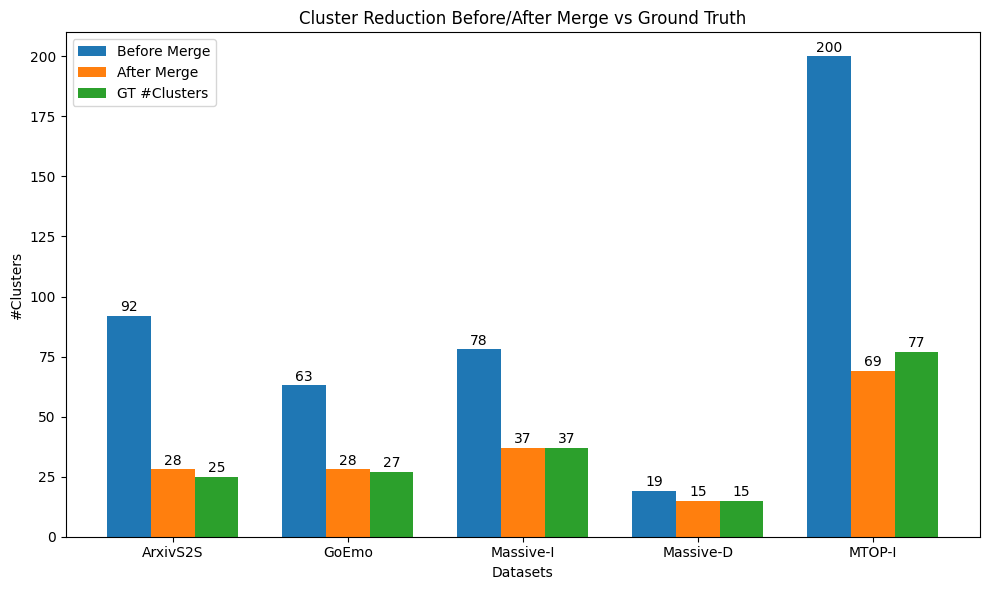

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# =========================
# DONNÉES (TES RÉSULTATS)
# =========================
datasets = ["ArxivS2S", "GoEmo", "Massive-I", "Massive-D", "MTOP-I"]

before_merge = [92, 63, 78, 19, 200]
after_merge = [28, 28, 37, 15, 69]
gt_clusters = [25, 27, 37, 15, 77]

# =========================
# POSITION DES BARRES
# =========================
x = np.arange(len(datasets))
width = 0.25  # largeur des barres

# =========================
# PLOT
# =========================
plt.figure(figsize=(10, 6))

plt.bar(x - width, before_merge, width, label="Before Merge")
plt.bar(x, after_merge, width, label="After Merge")
plt.bar(x + width, gt_clusters, width, label="GT #Clusters")

# =========================
# LABELS
# =========================
plt.xticks(x, datasets)
plt.ylabel("#Clusters")
plt.xlabel("Datasets")
plt.title("Cluster Reduction Before/After Merge vs Ground Truth")
plt.legend()

# =========================
# AJOUT DES VALEURS SUR LES BARRES
# =========================
for i in range(len(datasets)):
    plt.text(x[i] - width, before_merge[i] + 2, str(before_merge[i]), ha='center')
    plt.text(x[i], after_merge[i] + 2, str(after_merge[i]), ha='center')
    plt.text(x[i] + width, gt_clusters[i] + 2, str(gt_clusters[i]), ha='center')

plt.tight_layout()
plt.show()

In [ ]:
import shutil

shutil.make_archive("generated_labels_backup", "zip", "generated_labels")

'/content/generated_labels_backup.zip'

In [ ]:
from google.colab import files

files.download("generated_labels_backup.zip")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## **given label classification**

In [ ]:
!python given_label_classification.py --data arxiv_fine --api_key "Q14wFFcCeCi8KMv8SGHx7sOedaQQBYi9"

Use dataset ./dataset/arxiv_fine/small.jsonl
Length of dataset: 3674
Dataset truncated to: 1000 samples
Number of labels: 28
Processing 1/1000 (0.1%) | label: physics.app-ph
Processing 2/1000 (0.2%) | label: cs
Processing 3/1000 (0.3%) | label: cs
Processing 4/1000 (0.4%) | label: cs
Processing 5/1000 (0.5%) | label: cs
Processing 6/1000 (0.6%) | label: cs
Processing 7/1000 (0.7%) | label: physics.app-ph
Processing 8/1000 (0.8%) | label: cs
Processing 9/1000 (0.9%) | label: physics.app-ph
Processing 10/1000 (1.0%) | label: physics.app-ph
Processing 11/1000 (1.1%) | label: physics.app-ph
Processing 12/1000 (1.2%) | label: cs
Processing 13/1000 (1.3%) | label: cs
Processing 14/1000 (1.4%) | label: cs
Processing 15/1000 (1.5%) | label: physics.app-ph
Processing 16/1000 (1.6%) | label: physics.app-ph
Processing 17/1000 (1.7%) | label: physics.app-ph
Processing 18/1000 (1.8%) | label: cs
Processing 19/1000 (1.9%) | label: eess
Processing 20/1000 (2.0%) | label: cs
Processing 21/1000 (2.1%) 

In [ ]:
datasets = ["go_emotion", "massive_intent", "massive_scenario", "mtop_intent"]

for dataset in datasets:
    print(f"\n🚀 Running dataset: {dataset}\n")

    !python given_label_classification.py \
        --data {dataset} \
        --api_key "Q14wFFcCeCi8KMv8SGHx7sOedaQQBYi9"

    print(f"\n✅ Finished {dataset}\n")

    # 🔥 pause pour éviter surcharge API
    import time
    time.sleep(10)


🚀 Running dataset: go_emotion

Use dataset ./dataset/go_emotion/small.jsonl
Length of dataset: 5940
Dataset truncated to: 1000 samples
Number of labels: 28
Processing 1/1000 (0.1%) | label: guilt_regret
Processing 2/1000 (0.2%) | label: amusement_dark_humor
Processing 3/1000 (0.3%) | label: love_loyalty_admiration_gratitude
Processing 4/1000 (0.4%) | label: love_loyalty_admiration_gratitude
Processing 5/1000 (0.5%) | label: love_loyalty_admiration_gratitude
Processing 6/1000 (0.6%) | label: agreement_acknowledgment
Processing 7/1000 (0.7%) | label: excitement
Processing 8/1000 (0.8%) | label: reassurance_advice
Processing 9/1000 (0.9%) | label: criticism_disapproval
Processing 10/1000 (1.0%) | label: disappointment
Processing 11/1000 (1.1%) | label: worry_anxiety_concern_fear_panic
Processing 12/1000 (1.2%) | label: anger_annoyance_frustration_rage
Processing 13/1000 (1.3%) | label: disdain_contempt_disgust
Processing 14/1000 (1.4%) | label: amusement_dark_humor
Processing 15/1000 (1.

In [ ]:
datasets = [
    "arxiv_fine",
    "go_emotion",
    "massive_intent",
    "massive_scenario",
    "mtop_intent"
]

for dataset in datasets:
    print(f"\n🔵 Evaluating: {dataset}\n")

    !python evaluate.py \
        --data {dataset} \
        --predict_file {dataset}_small_classification.json

    print(f"\n🟢 Done: {dataset}\n")


🔵 Evaluating: arxiv_fine

Total ground truth labels: 1000
Total predicted labels: 1000
After filtering Unsuccessful: 989 samples

Ground truth labels:
Length of labels: 989
Number of Clusters: 25

Predicted labels:
Length of labels: 989
Number of Clusters: 26

Final Scores:
{'ACC': np.float64(0.38422649140546006), 'ARI': 0.27192965196897506, 'NMI': np.float64(0.5802121974289804)}

🟢 Done: arxiv_fine


🔵 Evaluating: go_emotion

Total ground truth labels: 1000
Total predicted labels: 1000
After filtering Unsuccessful: 996 samples

Ground truth labels:
Length of labels: 996
Number of Clusters: 27

Predicted labels:
Length of labels: 996
Number of Clusters: 28

Final Scores:
{'ACC': np.float64(0.2570281124497992), 'ARI': 0.100574908320918, 'NMI': np.float64(0.28810704691723354)}

🟢 Done: go_emotion


🔵 Evaluating: massive_intent

Total ground truth labels: 1000
Total predicted labels: 1000
After filtering Unsuccessful: 1000 samples

Ground truth labels:
Length of labels: 1000
Number of Cl

In [ ]:
!python evaluate.py \
--data arxiv_fine \
--predict_file arxiv_fine_small_classification.json

Total ground truth labels: 1000
Total predicted labels: 1000
After filtering Unsuccessful: 989 samples

Ground truth labels:
Length of labels: 989
Number of Clusters: 25

Predicted labels:
Length of labels: 989
Number of Clusters: 26

Final Scores:
{'ACC': np.float64(0.38422649140546006), 'ARI': 0.27192965196897506, 'NMI': np.float64(0.5802121974289803)}


| Dataset              | Metric | Paper | Moi   | Diff |
| -------------------- | ------ | ----- | ----- | ---- |
| **Arxiv**            | ACC    | 38.78 | 38.42 | ≈ OK |
|                      | NMI    | 57.43 | 58.02 | ↑    |
|                      | ARI    | 20.55 | 27.19 | ↑    |
| **GoEmotion**        | ACC    | 31.66 | 25.70 | ↓    |
|                      | NMI    | 27.39 | 28.81 | ↑    |
|                      | ARI    | 13.50 | 10.05 | ↓    |
| **Massive Intent**   | ACC    | 71.75 | 56.50 | ↓↓↓  |
|                      | NMI    | 78.00 | 74.67 | ↓    |
|                      | ARI    | 56.86 | 55.97 | ≈    |
| **Massive Scenario** | ACC    | 64.12 | 73.80 | ↑↑   |
|                      | NMI    | 65.44 | 74.71 | ↑    |
|                      | ARI    | 48.92 | 66.19 | ↑↑   |
| **MTOP Intent**      | ACC    | 72.18 | 55.45 | ↓↓↓  |
|                      | NMI    | 78.78 | 75.71 | ↓    |
|                      | ARI    | 71.93 | 51.46 | ↓↓↓  |
